In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
    ExtraTreesClassifier
)
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [ ]:
df = pd.read_csv("customer_info.csv")
print("Shape of Dataset:", df.shape)
print(df.head())

Shape of Dataset: (16978, 25)
   customer_id        customer_name customer_gender customer_birthdate  \
0        11259        Louis Huffman            male     8/22/1948 5:06   
1         6538       Msc. Noel Ward            male    2/12/1967 19:51   
2        14274  Bsc. Scott Giordano            male    4/10/1986 17:10   
3         7796         William Lacy            male      1/3/1999 1:47   
4         4521    Bsc. Nathan Minor            male    10/21/1957 7:34   

   kids_home  teens_home  number_complaints  distinct_stores_visited  \
0        0.0         2.0                2.0                      3.0   
1        2.0         1.0                3.0                      3.0   
2        0.0         0.0                1.0                      1.0   
3        0.0         1.0                1.0                      3.0   
4        3.0         1.0                2.0                      3.0   

   lifetime_spend_groceries  lifetime_spend_electronics  ...  \
0                      6238 

In [ ]:
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].fillna(df[col].mode()[0])
for col in df.select_dtypes(include=["int64", "float64"]).columns:
    df[col] = df[col].fillna(df[col].median())
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
customer_id                                0
customer_name                              0
customer_gender                            0
customer_birthdate                         0
kids_home                                  0
teens_home                                 0
number_complaints                          0
distinct_stores_visited                    0
lifetime_spend_groceries                   0
lifetime_spend_electronics                 0
typical_hour                               0
lifetime_spend_vegetables                  0
lifetime_spend_nonalcohol_drinks           0
lifetime_spend_alcohol_drinks              0
lifetime_spend_meat                        0
lifetime_spend_fish                        0
lifetime_spend_hygiene                     0
lifetime_spend_videogames                  0
lifetime_spend_petfood                     0
lifetime_total_distinct_products           0
percentage_of_products_bought_promotion    0
year_first_transaction                

In [ ]:
df["customer_birthdate"] = pd.to_datetime(
    df["customer_birthdate"],
    errors="coerce"
)
df["Age"] = 2026 - df["customer_birthdate"].dt.year
df.drop("customer_birthdate", axis=1, inplace=True)

In [ ]:
le = LabelEncoder()
for col in df.select_dtypes(include="object").columns:
    df[col] = le.fit_transform(df[col])

In [ ]:
target = "customer_gender"
X = df.drop(target, axis=1)
y = df[target]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
models = {
    "Logistic Regression":
        LogisticRegression(max_iter=1000),
    "KNN":
        KNeighborsClassifier(),
    "Decision Tree":
        DecisionTreeClassifier(random_state=42),
    "Random Forest":
        RandomForestClassifier(random_state=42),

    "SVM":
        SVC(),
    "Naive Bayes":
        GaussianNB(),
    "Gradient Boosting":
        GradientBoostingClassifier(random_state=42),
    "AdaBoost":
        AdaBoostClassifier(random_state=42),
    "Extra Trees":
        ExtraTreesClassifier(random_state=42)
}

In [ ]:
results = []
for name, model in models.items():
    print("\n" + "="*60)
    print(name)
    print("="*60)
    if name in [
        "Logistic Regression",
        "KNN",
        "SVM"
    ]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(
        y_test,
        y_pred,
        average="weighted"
    )
    recall = recall_score(
        y_test,
        y_pred,
        average="weighted"
    )
    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted"
    )
    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1
    ])
    print("Accuracy :", accuracy)
    print("Precision:", precision)
    print("Recall   :", recall)
    print("F1 Score :", f1)
    print("\nClassification Report")
    print(classification_report(y_test, y_pred))


Logistic Regression
Accuracy : 0.5076560659599529
Precision: 0.5071561521066758
Recall   : 0.5076560659599529
F1 Score : 0.5057787762255035

Classification Report
              precision    recall  f1-score   support

           0       0.51      0.57      0.54      1716
           1       0.50      0.45      0.47      1680

    accuracy                           0.51      3396
   macro avg       0.51      0.51      0.51      3396
weighted avg       0.51      0.51      0.51      3396


KNN
Accuracy : 0.5011778563015312
Precision: 0.5012465662335074
Recall   : 0.5011778563015312
F1 Score : 0.5011911782717564

Classification Report
              precision    recall  f1-score   support

           0       0.51      0.50      0.50      1716
           1       0.50      0.50      0.50      1680

    accuracy                           0.50      3396
   macro avg       0.50      0.50      0.50      3396
weighted avg       0.50      0.50      0.50      3396


Decision Tree
Accuracy : 0.735571

In [ ]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Algorithm",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)
results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)
print("\nFINAL RESULTS")
print(results_df)


FINAL RESULTS
             Algorithm  Accuracy  Precision    Recall  F1 Score
2        Decision Tree  0.735571   0.735571  0.735571  0.735546
6    Gradient Boosting  0.629859   0.631474  0.629859  0.628117
3        Random Forest  0.545053   0.545040  0.545053  0.543560
7             AdaBoost  0.528269   0.547669  0.528269  0.462478
8          Extra Trees  0.515312   0.514913  0.515312  0.513319
0  Logistic Regression  0.507656   0.507156  0.507656  0.505779
5          Naive Bayes  0.502650   0.502567  0.502650  0.502577
1                  KNN  0.501178   0.501247  0.501178  0.501191
4                  SVM  0.497939   0.497444  0.497939  0.496706


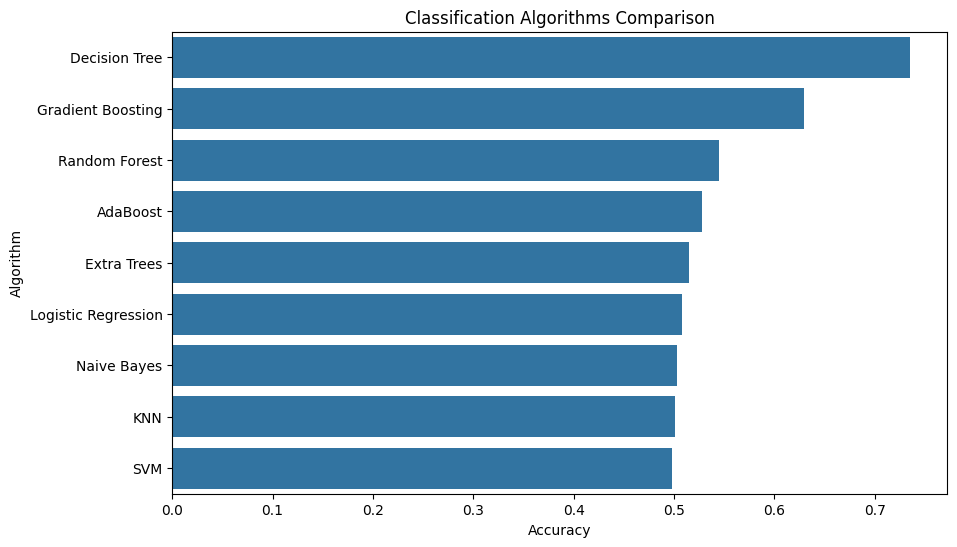

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=results_df,
    x="Accuracy",
    y="Algorithm"
)
plt.title("Classification Algorithms Comparison")
plt.show()

In [ ]:
best_model = results_df.iloc[0]
print("\nBest Model:")
print(best_model)


Best Model:
Algorithm    Decision Tree
Accuracy          0.735571
Precision         0.735571
Recall            0.735571
F1 Score          0.735546
Name: 2, dtype: object
